```text
原始采集顺序（raw.ch_names）:

编号  通道名   位置          大致区域
──────────────────────────────────────
 1   Fz      前额中央        ┐ 前部（额叶）
 2   FC3     额中央-左
 3   FC1     额中央-左中
 4   FCz     额中央
 5   FC2     额中央-右中
 6   FC4     额中央-右        ┘
 7   C5      中央-最左        ┐
 8   C3      中央-左          │
 9   C1      中央-左中        │ 中部（中央叶）
10   Cz      中央正中         │ ← 运动想象核心区域
11   C2      中央-右中        │
12   C4      中央-右          │
13   C6      中央-最右        ┘
14   CP3     中央顶-左        ┐
15   CP1     中央顶-左中      │ 后部（中央顶叶）
16   CPz     中央顶           │
17   CP2     中央顶-右中      │
18   CP4     中央顶-右        ┘
19   P1      顶叶-左中        ┐
20   Pz      顶叶中央         │ 顶部（顶叶）
21   P2      顶叶-右中        │
22   POz     顶枕中央         ┘

+ 3 个 EOG 通道（眼电）

```

In [2]:
"""
BNCI2014_001 数据集完整 Demo
数据集: BCI Competition IV - Dataset 2a (4类运动想象)
"""

import numpy as np
import matplotlib.pyplot as plt
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
import os
import mne

# 数据集
data_dir = os.path.abspath("./../datasets")
mne.set_config("MNE_DATA", data_dir)
dataset = BNCI2014_001()
dataset.download()

# ============================================================
# 1. 加载数据集
# ============================================================
print("=" * 60)
print("1. 加载数据集")
print("=" * 60)

dataset = BNCI2014_001()
dataset.download()

print(f"数据集代码 : {dataset.code}")
print(f"被试列表   : {dataset.subject_list}")
print(f"默认 interval: {dataset.interval}")
print()

1. 加载数据集
数据集代码 : BNCI2014-001
被试列表   : [1, 2, 3, 4, 5, 6, 7, 8, 9]
默认 interval: [2, 6]



In [3]:
# ============================================================
# 2. 打印 metadata
# ============================================================
print("=" * 60)
print("2. 数据集元信息")
print("=" * 60)

meta = dataset.metadata # 数据集元信息
a = meta.acquisition # 数据采集信息
p = meta.participants # 被试信息
e = meta.experiment # 实验信息
d = meta.documentation # 文献信息
pp = meta.preprocessing # 预处理信息

print(f"数据集描述  : {d.description}")
print(f"研究者      : {', '.join(d.investigators[:3])} ...")
print(f"机构        : {d.institution}")
print(f"论文DOI     : {d.doi}")
print(f"许可证      : {d.license}")
print(f"发表年份    : {d.publication_year}")
print()

print(f"被试人数    : {p.n_subjects}")
print(f"健康状态    : {p.health_status}")
print(f"物种        : {p.species}")
print()

print(f"范式类型    : {e.paradigm}")
print(f"类别数      : {e.n_classes}")
print(f"类别标签    : {e.class_labels}")
print(f"事件定义    : {e.events}")
print(f"试次时长    : {e.trial_duration} s")
print(f"刺激类型    : {e.stimulus_type}")
print(f"实验模式    : {e.mode}")
print(f"实验指导语  : {e.instructions}")
print()

print(f"采样率      : {a.sampling_rate} Hz")
print(f"通道数      : {a.n_channels}")
print(f"通道类型    : {a.channel_types}")
print(f"传感器      : {a.sensors}")
print(f"硬件        : {a.hardware}")
print(f"实验软件    : {a.software}")
print(f"参考电极    : {a.reference}")
print()

print(f"预处理状态  : {pp.data_state}")
print(f"滤波范围    : {pp.highpass_hz} ~ {pp.lowpass_hz} Hz")
print(f"重采样频率  : {pp.downsampled_to_hz} Hz")
print()

print(f"sessions数  : {meta.sessions_per_subject}")
print(f"runs/session: {meta.runs_per_session}")
print(f"文件格式    : {meta.file_format}")
print()

# ============================================================
# 3. 打印 metadata 结构化摘要
# ============================================================
print("=" * 60)
print("3. 结构化摘要")
print("=" * 60)

print("┌" + "─" * 58 + "┐")
print(f"│ {'BNCI2014_001 数据集摘要':^54s} │")
print("├" + "─" * 58 + "┤")
print(f"│ 被试数    : {p.n_subjects:<45d} │")
print(f"│ 健康状态  : {p.health_status:<45s} │")
print(f"│ 类别数    : {e.n_classes:<45d} │")
print(f"│ 类别标签  : {str(e.class_labels):<45s} │")
print(f"│ 试次时长  : {e.trial_duration:<45.1f} │")
print(f"│ 采样率    : {a.sampling_rate:<45.1f} │")
print(f"│ 通道数    : {a.n_channels:<45d} │")
print(f"│ EEG通道数 : {str(a.channel_types.get('eeg', 'N/A')):<45s} │")
print(f"│ 硬件      : {a.hardware:<45s} │")
print(f"│ 滤波范围  : {pp.highpass_hz}~{pp.lowpass_hz} Hz{'':<35s} │")
print(f"│ DOI       : {d.doi:<45s} │")
print(f"│ 许可证    : {d.license:<45s} │")
print("└" + "─" * 58 + "┘")
print()

# ============================================================
# 4. 用 MotorImagery paradigm 提取 epoch 数据
# ============================================================
print("=" * 60)
print("4. 提取 Epoch 数据")
print("=" * 60)

dataset.interval = [1, 4]  # 事件后 1~4 秒（默认值）

paradigm = MotorImagery(
    fmin=4.0,
    fmax=38.0,
)

subject_id = [1]
X, y, epoch_metadata = paradigm.get_data(dataset=dataset, subjects=subject_id)

print(f"X shape : {X.shape}  (trials, channels, samples)")
print(f"y shape : {y.shape}")
print(f"标签类别: {np.unique(y)}")
print()

# 各类别样本数
print("类别分布:")
for label in np.unique(y):
    count = np.sum(y == label)
    print(f"  {label:12s} : {count} trials")
print()

print("epoch_metadata 前 5 行:")
print(epoch_metadata.head())
print()

# ============================================================
# 5. 多被试加载
# ============================================================
print("=" * 60)
print("5. 多被试加载")
print("=" * 60)

subject_ids = [1, 2, 3]
X_multi, y_multi, meta_multi = paradigm.get_data(dataset=dataset, subjects=subject_ids)

print(f"被试 {subject_ids} 总样本数: {X_multi.shape[0]}")
for sid in subject_ids:
    mask = meta_multi['subject'] == sid
    print(f"  Subject {sid} : {mask.sum()} trials")
print()


Choosing from all possible events


2. 数据集元信息
数据集描述  : Review of the BCI competition IV - Data set 1: Asynchronous Motor Imagery
研究者      : Michael Tangermann, Klaus-Robert Müller, Ad Aertsen ...
机构        : Berlin Institute of Technology
论文DOI     : 10.3389/fnins.2012.00055
许可证      : CC-BY-ND-4.0
发表年份    : 2012

被试人数    : 9
健康状态    : healthy
物种        : human

范式类型    : imagery
类别数      : 4
类别标签    : ['left_hand', 'right_hand', 'feet', 'tongue']
事件定义    : {'left_hand': 1, 'right_hand': 2, 'foot': 3, 'no_control': 0}
试次时长    : 4.0 s
刺激类型    : arrow_cue
实验模式    : offline
实验指导语  : Subjects instructed to perform motor imagery during cued periods

采样率      : 250.0 Hz
通道数      : 25
通道类型    : {'eeg': 22, 'eog': 3}
传感器      : ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CPz', 'Cz', 'EOG1', 'EOG2', 'EOG3', 'FC1', 'FC2', 'FC3', 'FC4', 'FCz', 'Fz', 'P1', 'P2', 'POz', 'Pz']
硬件        : BrainAmp MR plus
实验软件    : BCI2000
参考电极    : left mastoid

预处理状态  : minimally preprocessed (bandpass and notch filtered)
滤波范围 

6. 可视化


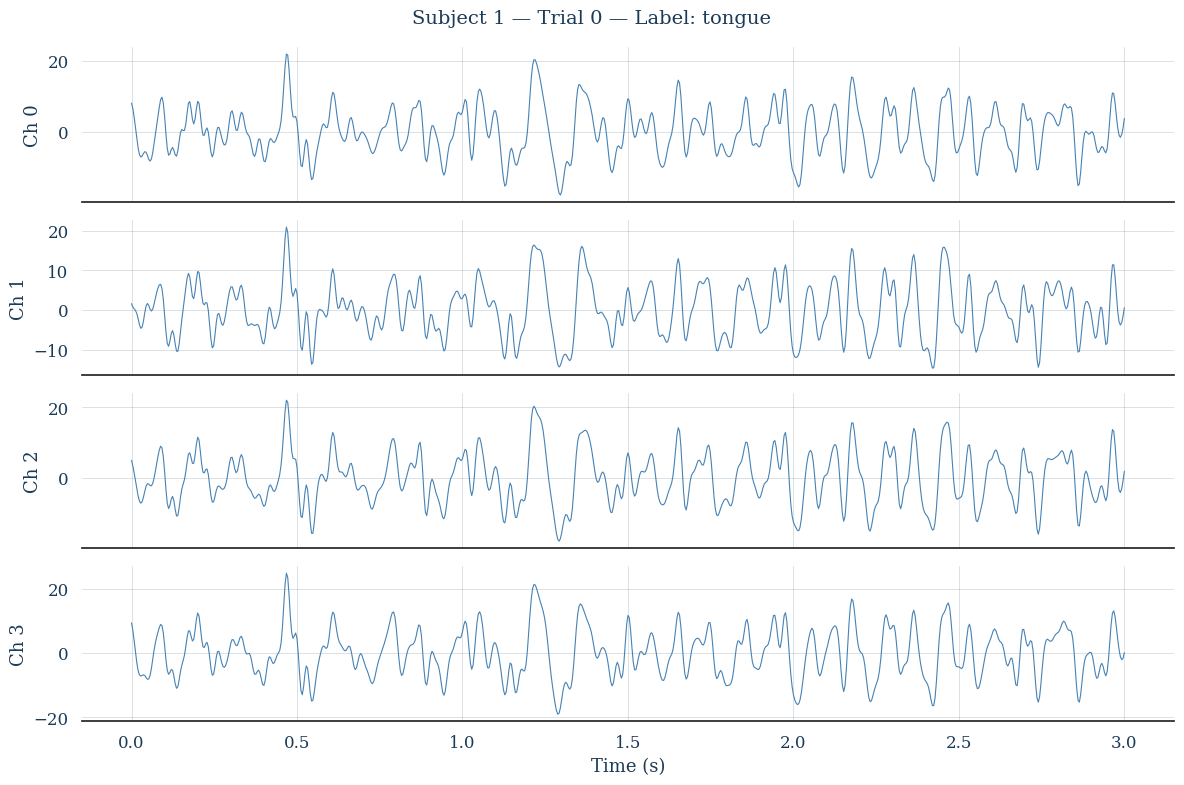

In [4]:
# ============================================================
# 6. 可视化 — 各类别平均 ERP
# ============================================================
print("=" * 60)
print("6. 可视化")
print("=" * 60)

sfreq = a.sampling_rate
n_samples = X.shape[2]
t = np.arange(n_samples) / sfreq



# 6a. 单 trial 信号（前 4 个通道）
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Subject 1 — Trial 0 — Label: {y[0]}", fontsize=14)

#X(trial, channel, sample_time)
for i in range(4):
    axes[i].plot(t, X[0, i, :], linewidth=0.8, color='steelblue')
    axes[i].set_ylabel(f"Ch {i}")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


['feet' 'left_hand' 'right_hand' 'tongue']


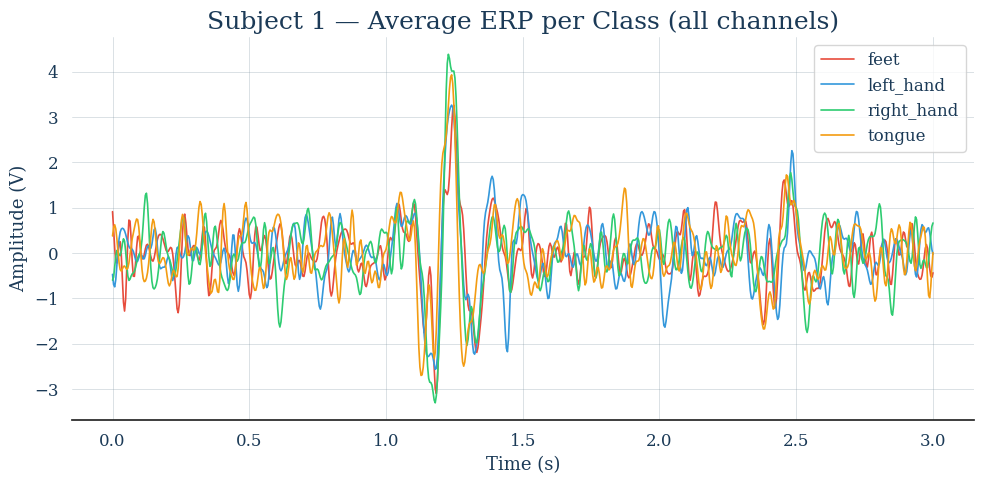

In [5]:

# 6b. 各类别平均 ERP（所有通道取平均）
fig, ax = plt.subplots(figsize=(10, 5))

labels = np.unique(y)
print(labels)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for label, color in zip(labels, colors):
    mask = y == label
    avg_erp = X[mask].mean(axis=(0, 1))  # 先对 trials 取平均，再对 channels 取平均
    ax.plot(t, avg_erp, label=label, color=color, linewidth=1.2)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (V)")
ax.set_title("Subject 1 — Average ERP per Class (all channels)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



数据集通道名: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CPz', 'Cz', 'EOG1', 'EOG2', 'EOG3', 'FC1', 'FC2', 'FC3', 'FC4', 'FCz', 'Fz', 'P1', 'P2', 'POz', 'Pz']
{'C3': 2, 'Cz': 11, 'C4': 3}


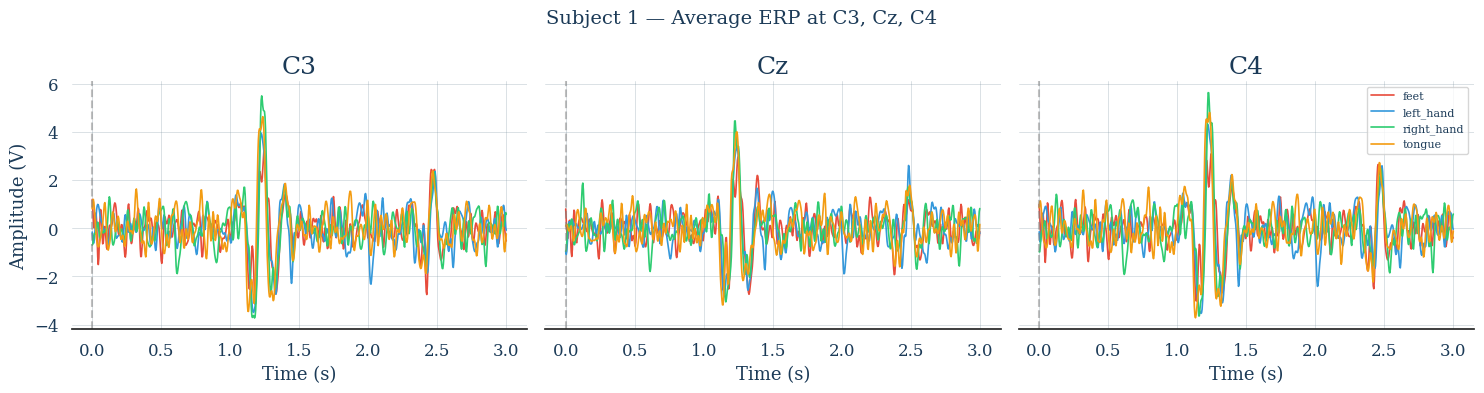


Demo 完成


In [6]:
# 6c. 各类别在 C3、Cz、C4 的平均 ERP
# 先确认通道名
ch_names = a.sensors
print(f"\n数据集通道名: {ch_names}")

# 尝试找到 C3、Cz、C4 通道索引
target_channels = {}
for target in ['C3', 'Cz', 'C4']:
    for idx, ch in enumerate(ch_names):
        if ch == target:
            target_channels[target] = idx
            break
print(target_channels)

if len(target_channels) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"Subject 1 — Average ERP at C3, Cz, C4", fontsize=14)

    for ax, (ch_name, ch_idx) in zip(axes, target_channels.items()):
        for label, color in zip(labels, colors):
            mask = y == label
            avg_erp = X[mask][:, ch_idx, :].mean(axis=0) # 对 trials 取平均,指定通道
            ax.plot(t, avg_erp, label=label, color=color, linewidth=1.2)
        ax.set_title(ch_name)
        ax.set_xlabel("Time (s)")
        ax.grid(True, alpha=0.3)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

    axes[0].set_ylabel("Amplitude (V)")
    axes[-1].legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print(f"未找到全部目标通道 (找到: {target_channels})，跳过 C3/Cz/C4 可视化")

print()
print("=" * 60)
print("Demo 完成")
print("=" * 60)

